Example of how to parse the files and load data in dataframes.

In [35]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import math
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [36]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

/Users/filipnordqvist/Documents/GitHub/Examensarbete/data


In [37]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [38]:
# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)

noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [39]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_12
Loading test:  12_5
Loading test:  12_2
Loading test:  12_3
Loading test:  12_4
Loading test:  12_10
Loading test:  12_11
Loading test:  12_1
Loading test:  12_6
Loading test:  12_8
Loading test:  12_9
Loading test:  12_7
Loading test:  12_0
Loading test:  12_13
Loading test:  12_12
---------------------------------------------
Loading walking data for subject:  subject_15
---------------------------------------------
Loading walking data for subject:  subject_14
Loading test:  14_9
Loading test:  14_0
Loading test:  14_7
Loading test:  14_6
Loading test:  14_1
Loading test:  14_8
Loading test:  14_14
Loading test:  14_13
Loading test:  14_12
Loading test:  14_4
Loading test:  14_3
Loading test:  14_2
Loading test:  14_5
Loading test:  14_10
Loading test:  14_11
---------------------------------------------
Loading walking data for subject:  subject_13
Loading test:  13_11
Loading test:  13_10
L

In [40]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
print("Events: ", selection[0].events.head())
print("Motion: ", selection[0].motion.head())
print("Orientation: ", selection[0].orientation.head())
print("Positions: ", selection[0].positions.head())
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  12_5
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0      961.0  241776.000023
Motion:     Unnamed: 0     ms    accelX    accelY    accelZ  accelWithGX  accelWithGY  \
0           0  301.0  0.438315 -0.063984 -0.070899    -0.022308     1.661179   
1           1  326.0  0.498090 -0.201496  0.016141    -0.035461     1.648026   
2           2  344.0  0.458053 -0.219058 -0.166888    -0.171860     1.747330   
3           3  366.0  0.212662 -0.051397 -0.305197    -0.256805     1.845428   
4           4  383.0  0.212662 -0.051397 -0.305197    -0.429092     1.931564   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0     9.639145      2.197900     3.448972      7.877995        16  
1     9.442932      5.656489     1.173263      5.241214        16  
2     9.349625      6.130341     0.611111      3.747971        16  
3     9.267059      7.771335     2.842233      4.861783        16  
4     9.143829 

In [41]:
#Saras code
def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371  # km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) * math.sin(dLat / 2) + \
        math.sin(dLon / 2) * math.sin(dLon / 2) * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000

Total distance traveled for 12_5: 261.31 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.961    4.410446         0.961   4.589434
2   1.926    2.864023         0.965   2.967900
3   2.921    1.738684         0.995   1.747421
4   3.935    0.591231         1.014   0.583068
5   4.929    1.441771         0.994   1.450474
6   5.927    2.224301         0.998   2.228758
7   6.925    1.754596         0.998   1.758112
8   7.931    1.126506         1.006   1.119787
9   8.926    0.826997         0.995   0.831152


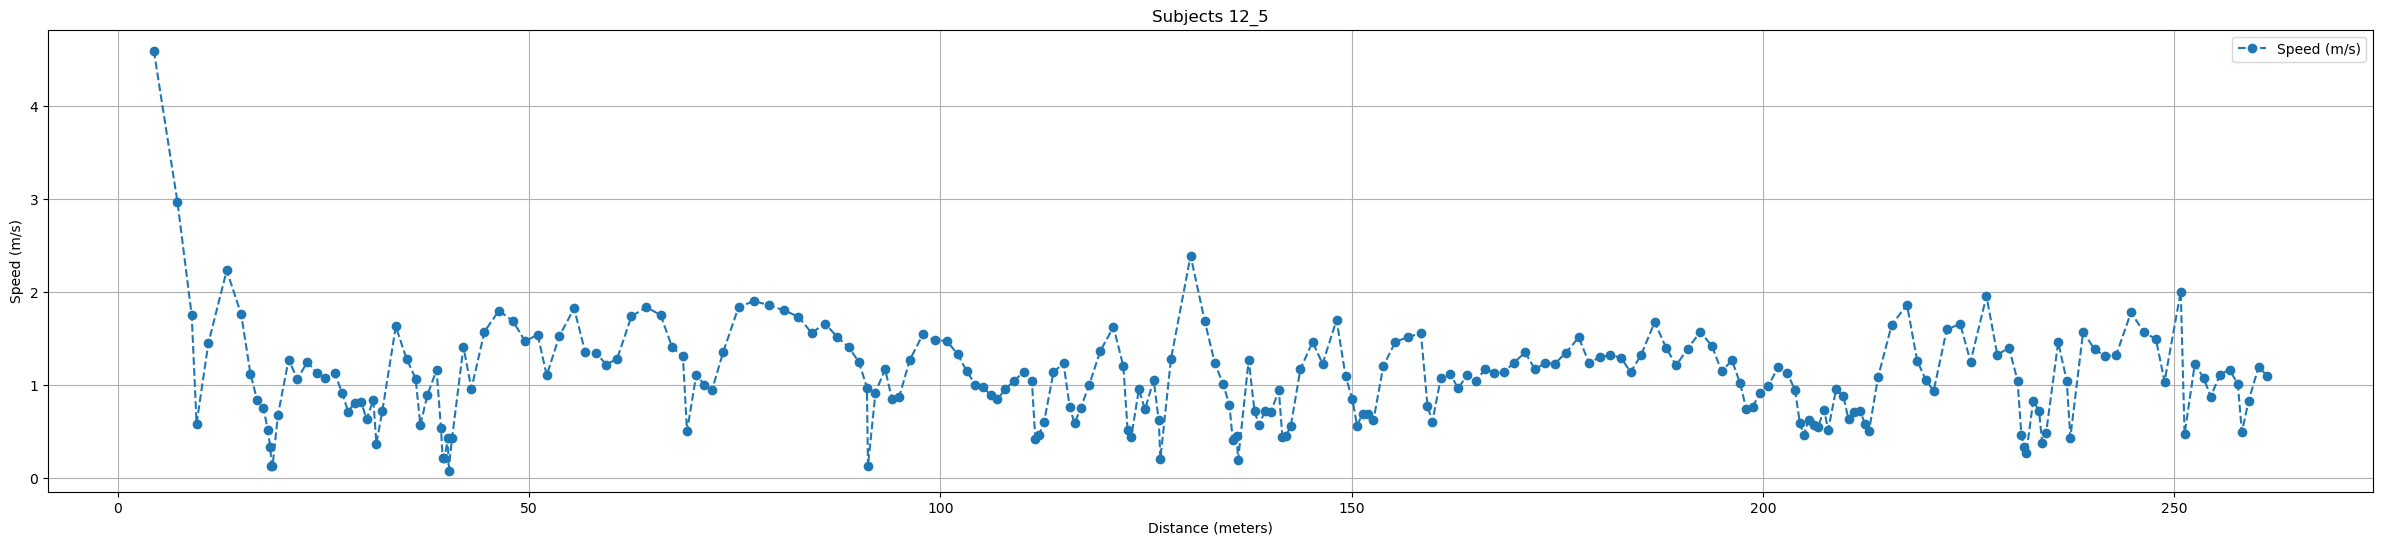

Total distance traveled for 12_2: 536.30 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.562   26.149041         0.562  46.528542
2   1.519    5.074917         0.957   5.302943
3   2.528   19.395669         1.009  19.222665
4   3.537    1.871440         1.009   1.854747
5   3.988    0.888906         0.451   1.970967
6   4.981    7.218676         0.993   7.269563
7   5.968    1.969949         0.987   1.995895
8   6.996    0.427751         1.028   0.416101
9   7.954    1.315478         0.958   1.373150


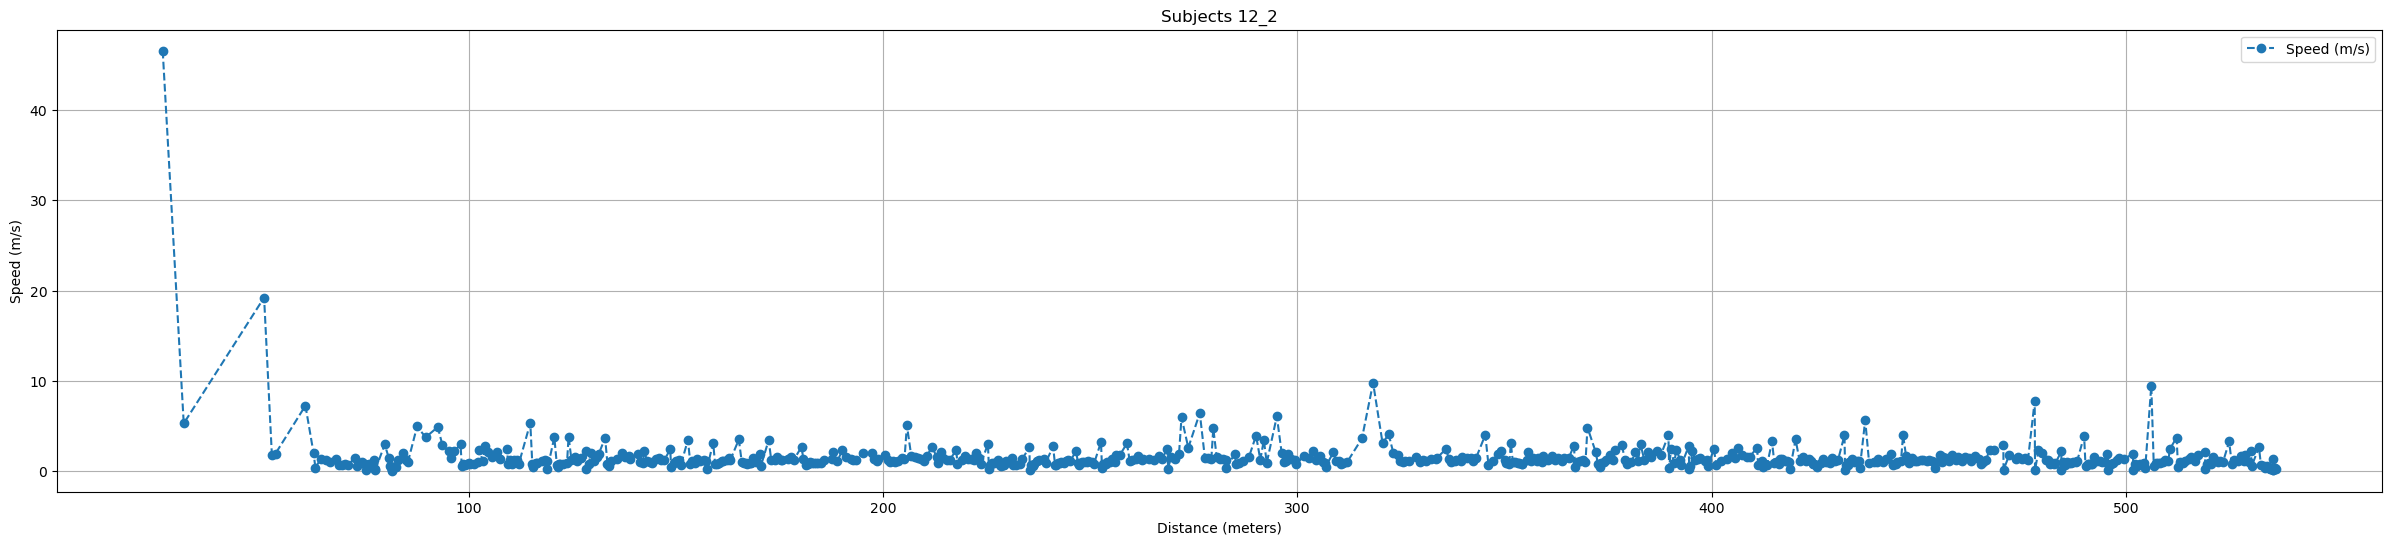

Total distance traveled for 12_3: 465.94 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.924    2.267270         0.924   2.453755
2   1.939   15.302320         1.015  15.076178
3   2.654    9.553001         0.715  13.360841
4   3.644    3.255806         0.990   3.288693
5   4.694    5.593788         1.050   5.327418
6   5.670    2.333241         0.976   2.390616
7   6.642    3.606773         0.972   3.710672
8   7.653    5.231615         1.011   5.174693
9   8.648    4.096154         0.995   4.116737


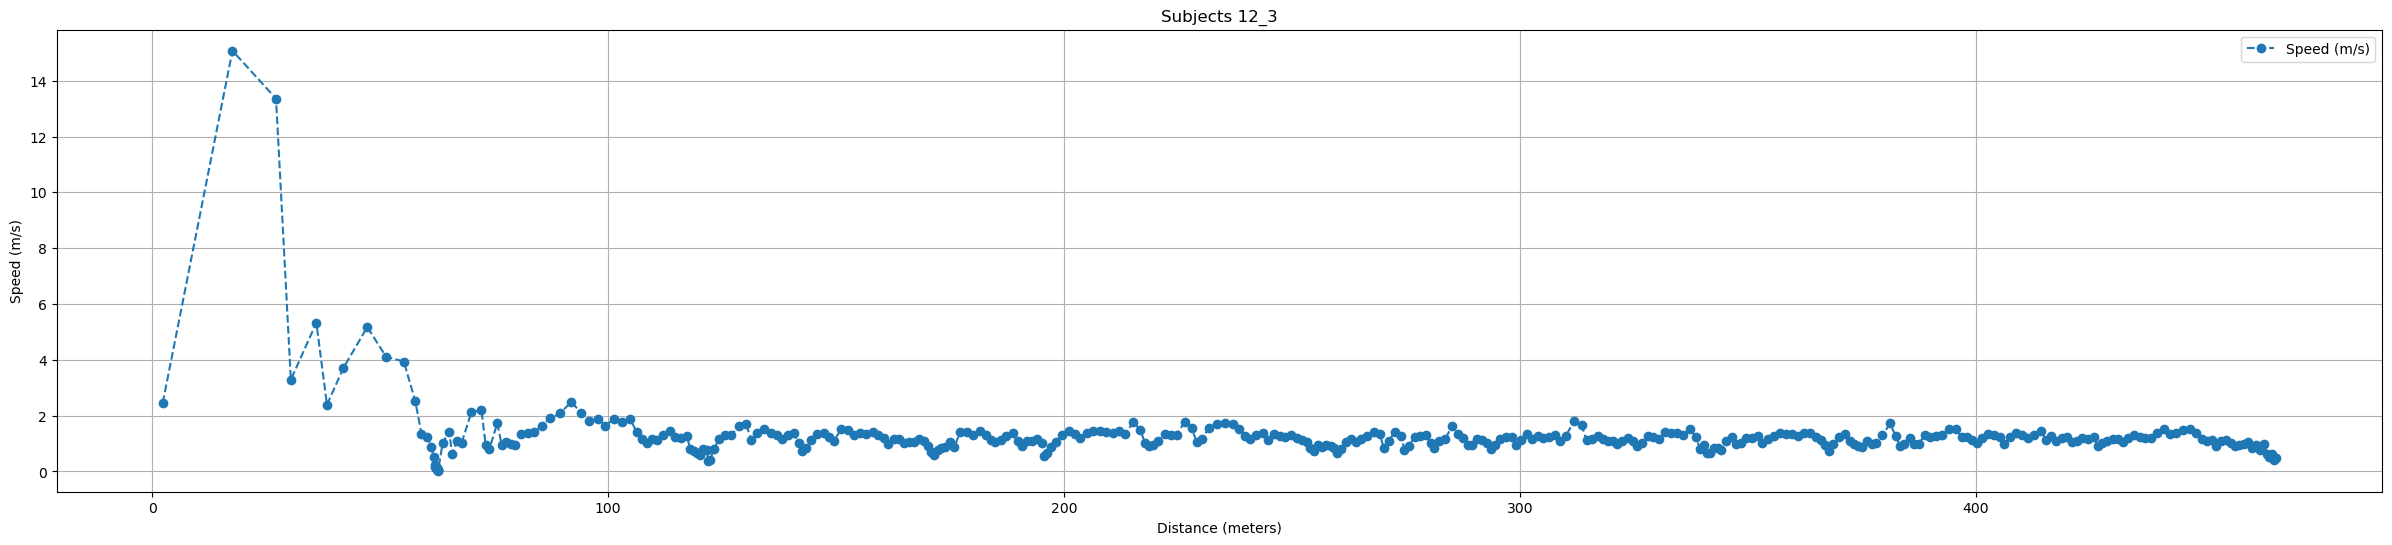

Total distance traveled for 12_4: 331.33 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.983   11.299450         0.983  11.494863
2   1.983    3.722071         1.000   3.722071
3   3.000    1.094487         1.017   1.076191
4   3.994    0.510774         0.994   0.513858
5   4.971    0.476378         0.977   0.487593
6   5.992    1.175932         1.021   1.151745
7   6.993    0.565681         1.001   0.565116
8   7.995    0.503560         1.002   0.502555
9   8.987    0.700640         0.992   0.706290


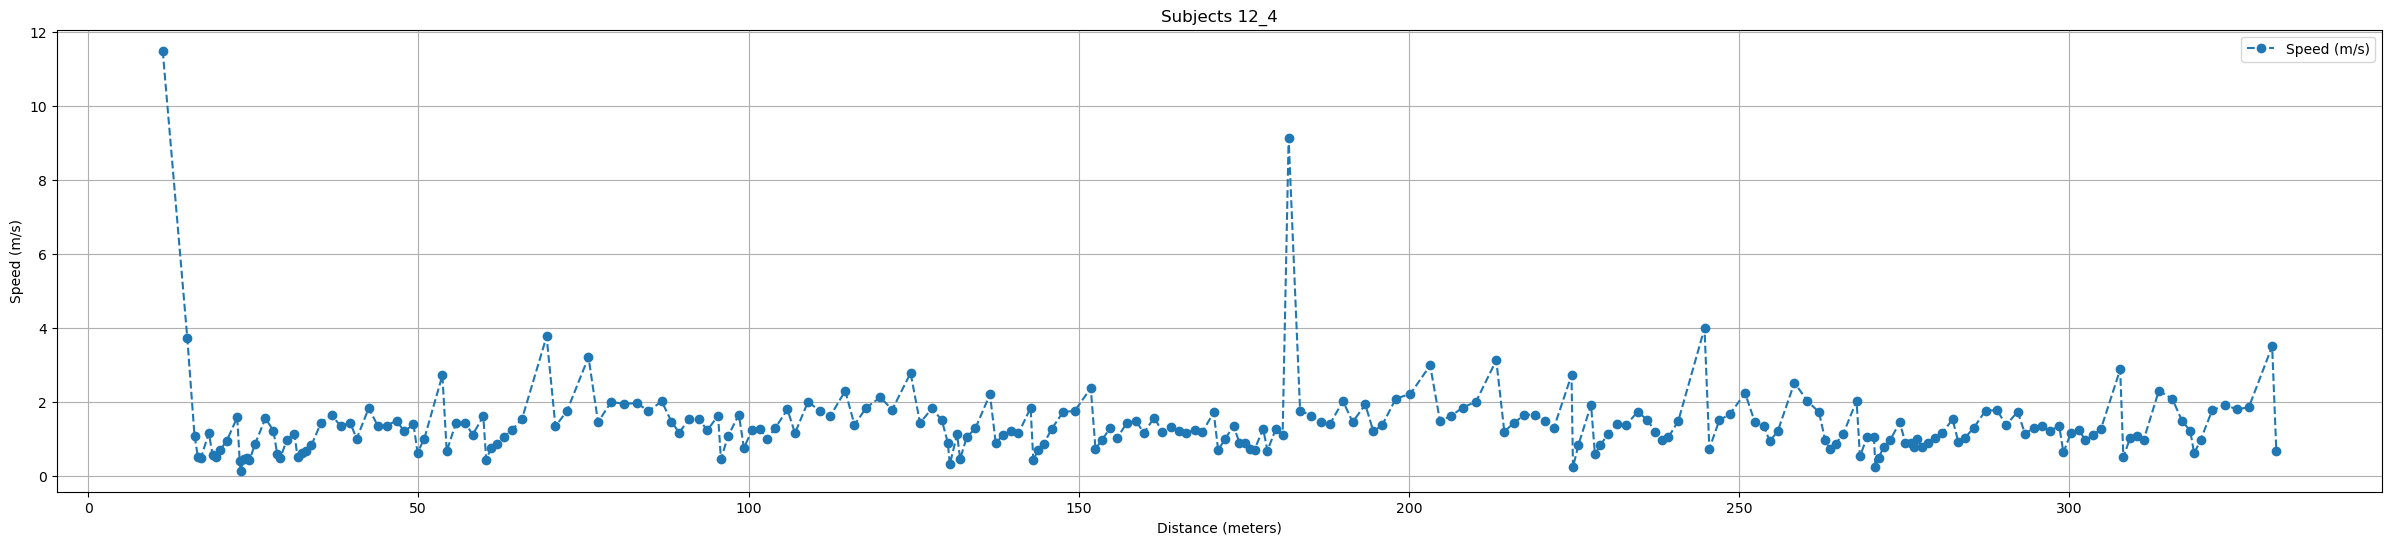

Total distance traveled for 12_10: 350.25 meters
   time_s  distance_m  delta_time_s   speed_mps
0   0.000    0.000000           NaN         NaN
1   0.199   21.419976         0.199  107.638071
2   1.210    1.801135         1.011    1.781538
3   2.233    0.898572         1.023    0.878369
4   3.190    1.080606         0.957    1.129160
5   4.217    2.204109         1.027    2.146163
6   5.196    1.814522         0.979    1.853444
7   6.216    1.221459         1.020    1.197508
8   7.197    0.554613         0.981    0.565355
9   8.197    0.756591         1.000    0.756591


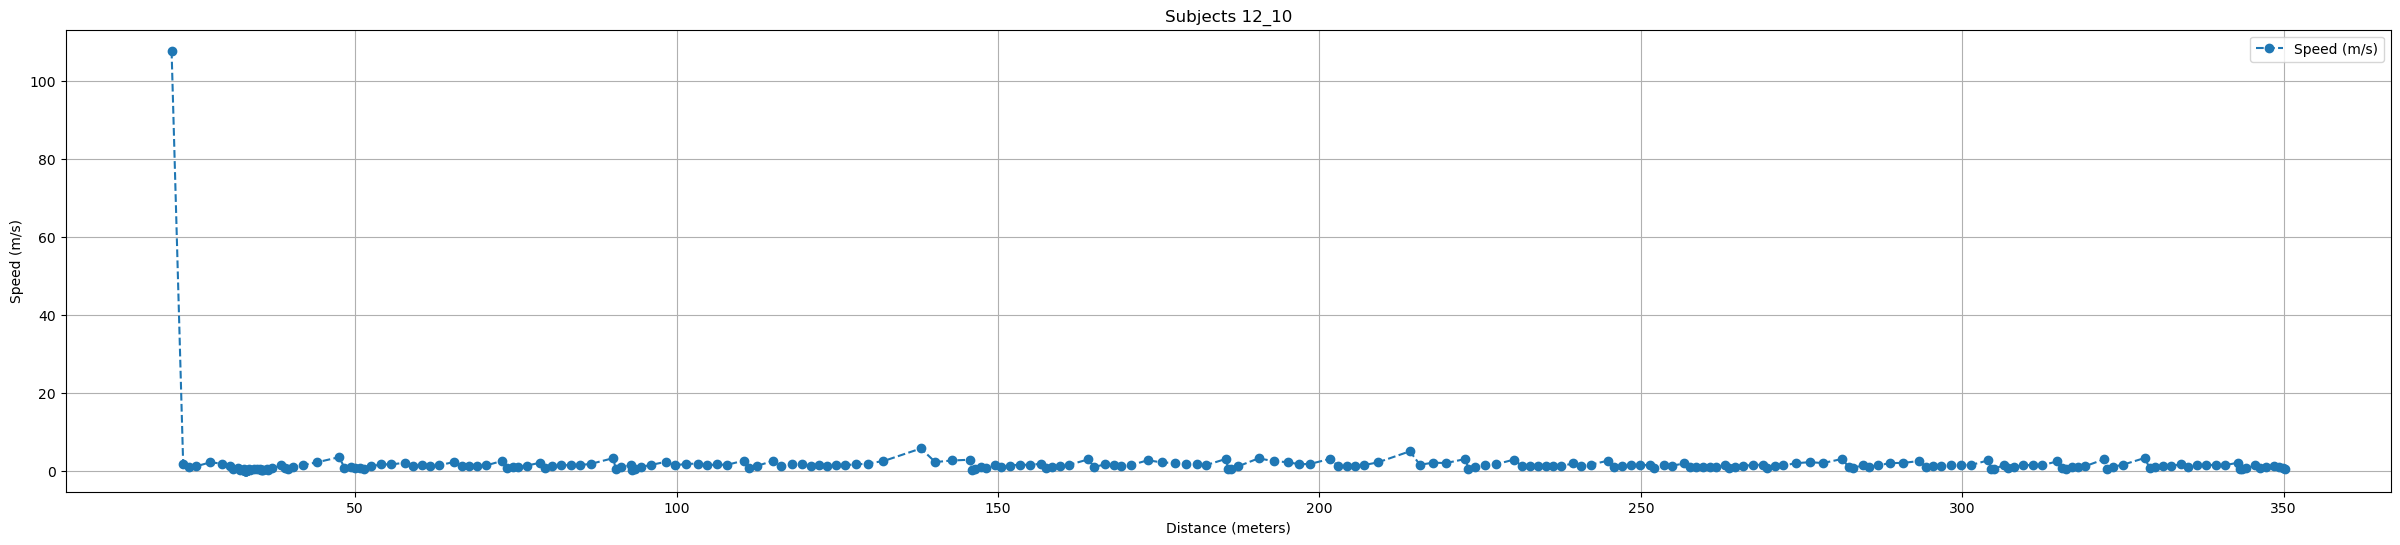

Total distance traveled for 12_11: 267.03 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.924    2.965552         0.924   3.209472
2   1.921    0.582230         0.997   0.583982
3   2.923    0.507589         1.002   0.506576
4   3.926    1.682543         1.003   1.677510
5   4.913    1.723063         0.987   1.745758
6   5.910    0.710526         0.997   0.712664
7   6.927    0.490024         1.017   0.481833
8   7.937    0.546538         1.010   0.541127
9   8.919    0.613119         0.982   0.624357


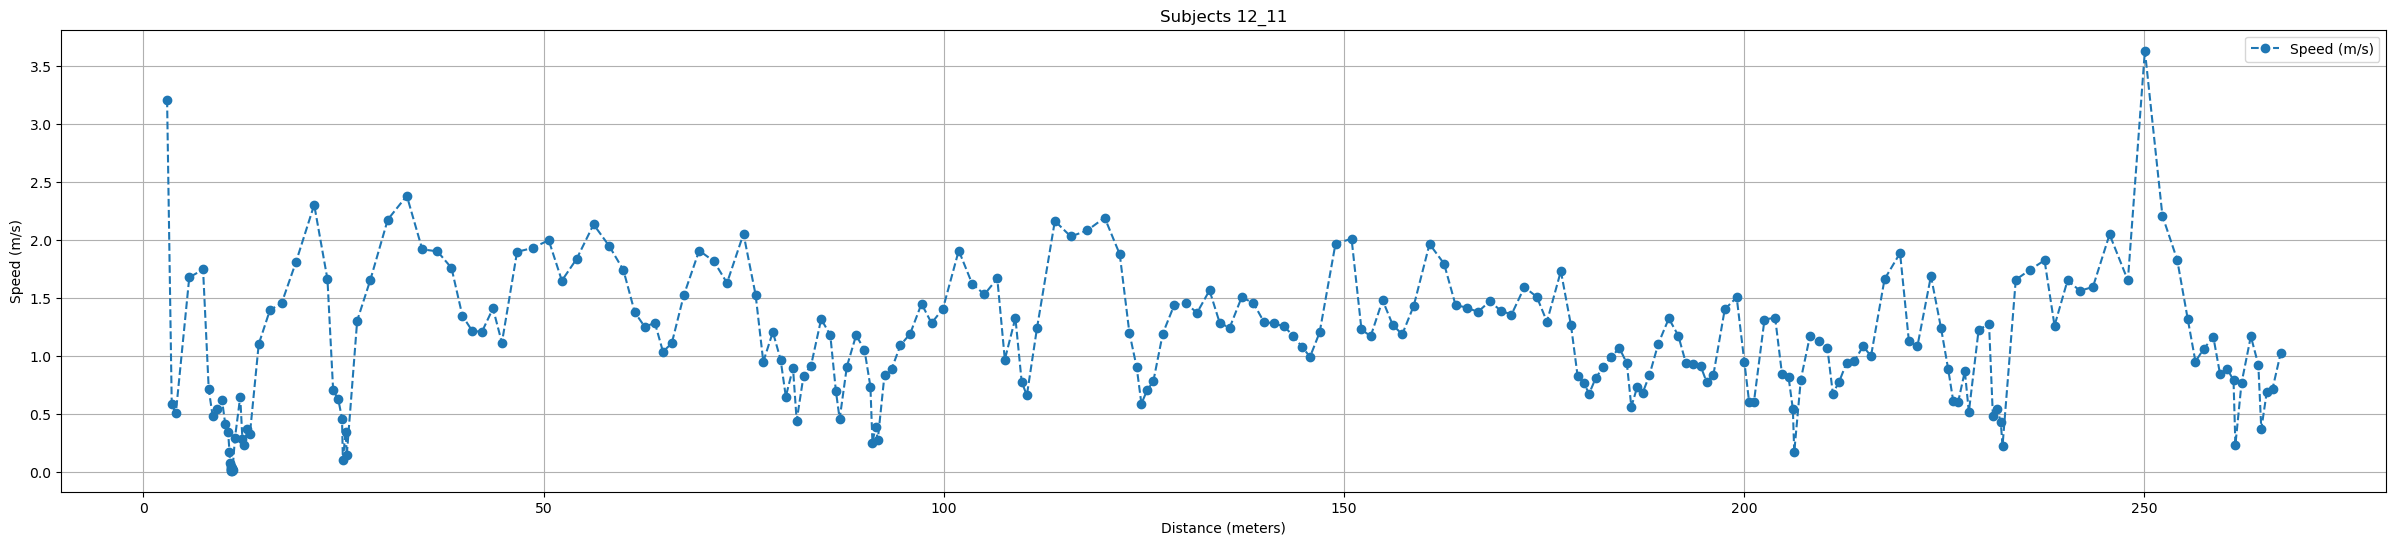

Total distance traveled for 12_1: 402.64 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.967    0.169197         0.967   0.174971
2   1.955    0.432204         0.988   0.437453
3   2.955    0.442413         1.000   0.442413
4   3.958    0.319536         1.003   0.318581
5   4.959    0.367417         1.001   0.367050
6   5.953    0.227292         0.994   0.228664
7   6.957    0.374604         1.004   0.373111
8   7.971    0.726089         1.014   0.716064
9   8.967    0.942295         0.996   0.946079


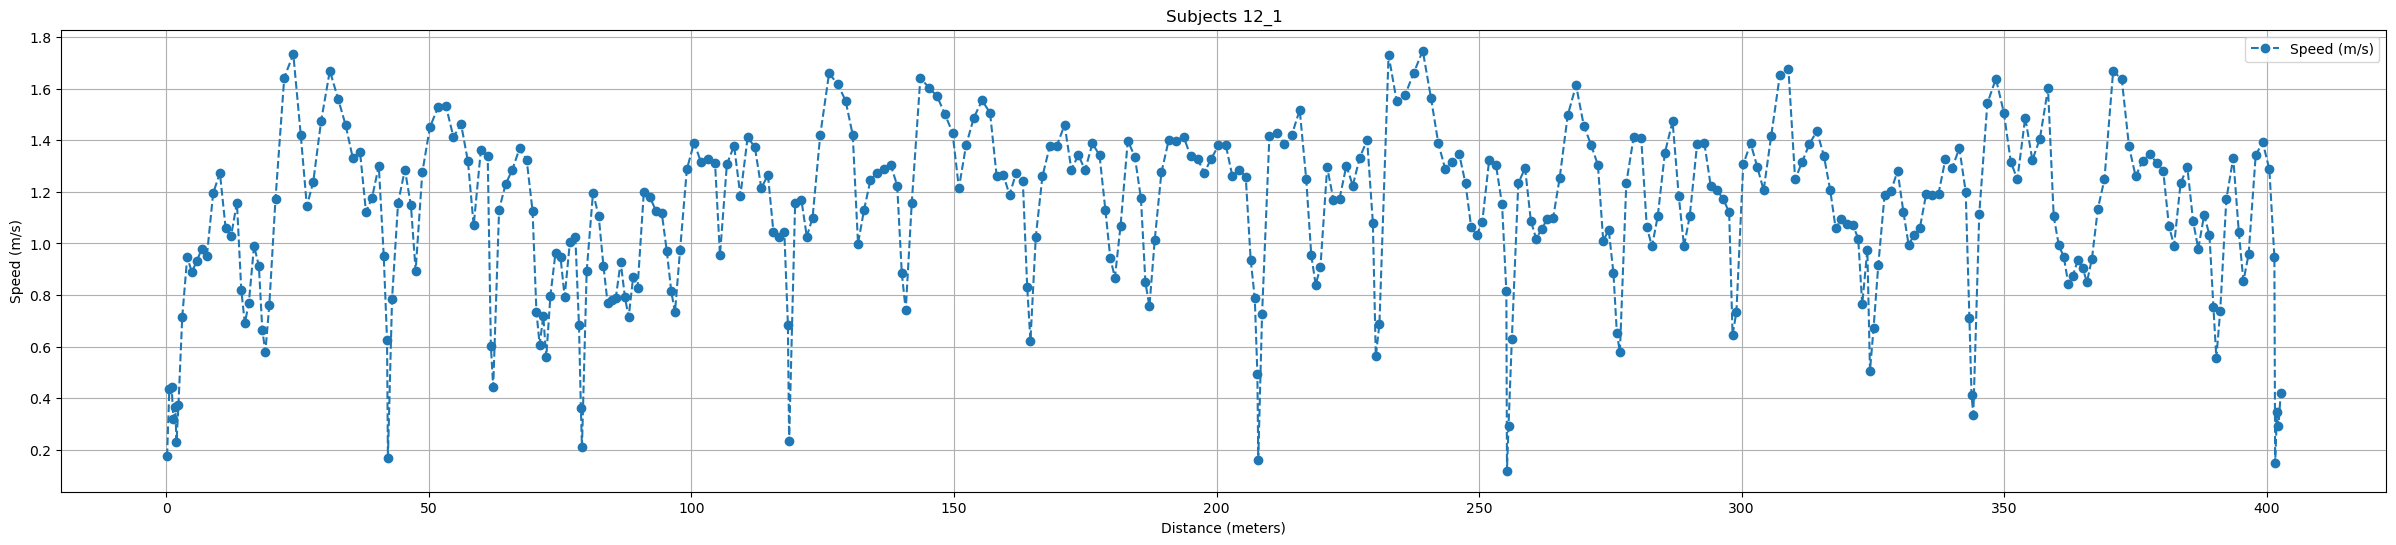

Total distance traveled for 12_6: 255.49 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.657    0.566071         0.657   0.861600
2   1.692    0.383121         1.035   0.370165
3   2.677    0.790323         0.985   0.802358
4   3.691    1.250017         1.014   1.232758
5   4.693    1.304929         1.002   1.302324
6   5.684    1.000019         0.991   1.009101
7   6.685    1.058034         1.001   1.056977
8   7.684    0.284289         0.999   0.284573
9   8.695    0.435643         1.011   0.430903


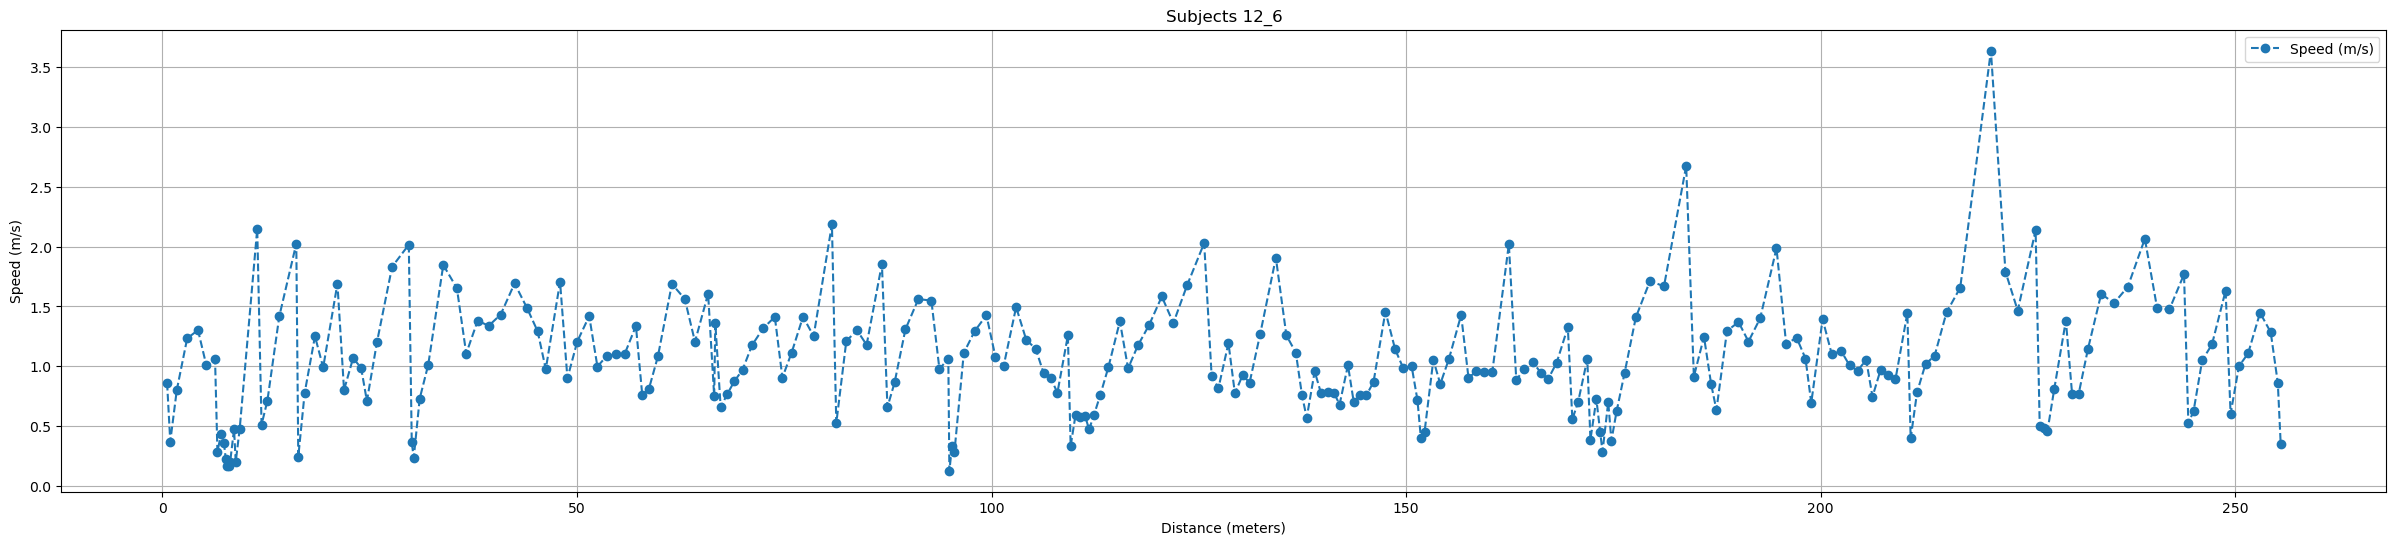

Total distance traveled for 12_8: 326.20 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.059    3.056559         0.100  30.565587
2   1.084    2.451630         1.025   2.391834
3   2.085    1.512910         1.001   1.511399
4   3.087    1.772259         1.002   1.768722
5   4.054    1.246376         0.967   1.288910
6   5.065    1.225980         1.011   1.212641
7   6.085    0.235740         1.020   0.231117
8   7.089    0.605164         1.004   0.602753
9   8.077    0.367300         0.988   0.371761


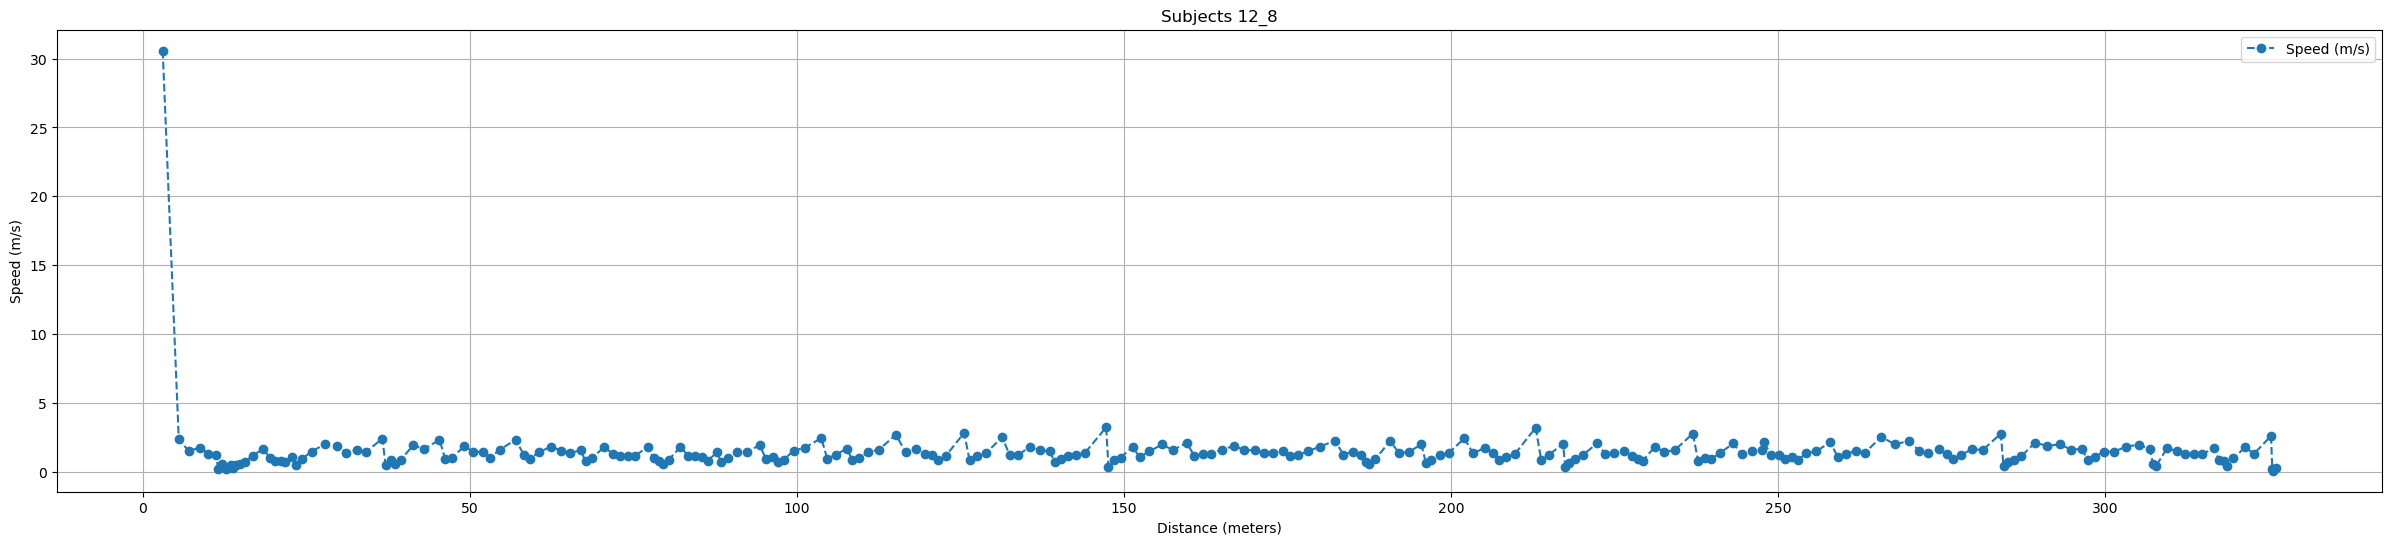

Total distance traveled for 12_9: 238.42 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.970    2.459512         0.970   2.535580
2   1.939    3.177136         0.969   3.278778
3   2.938    3.435932         0.999   3.439371
4   3.942    3.055610         1.004   3.043436
5   4.951    2.660660         1.009   2.636928
6   5.957    2.207230         1.006   2.194065
7   6.953    1.794295         0.996   1.801501
8   7.957    1.502664         1.004   1.496677
9   8.963    0.970724         1.006   0.964935


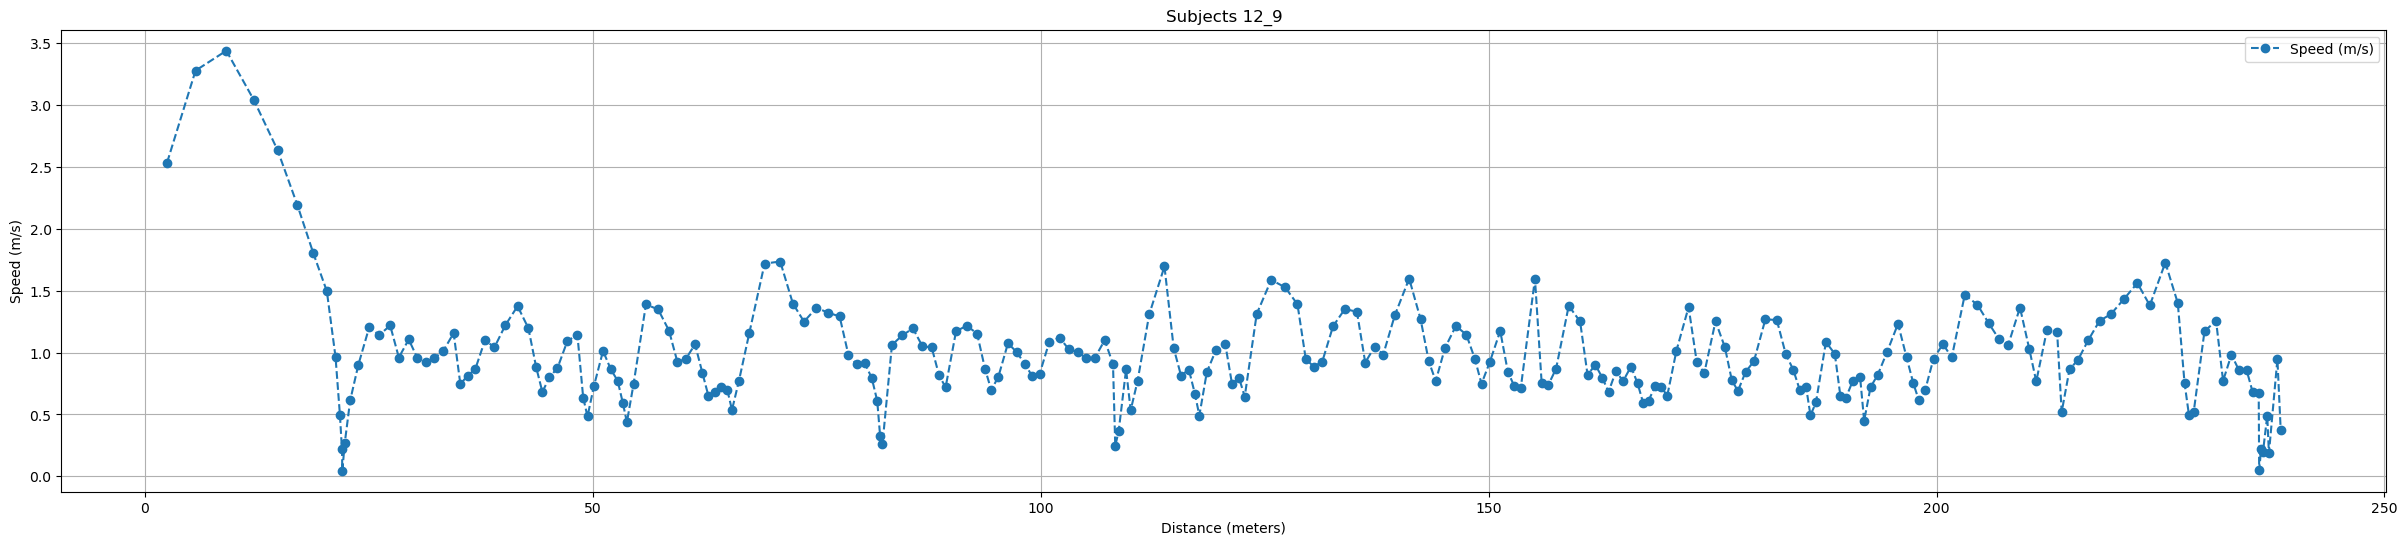

Total distance traveled for 12_7: 239.40 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.956    1.114936         0.956   1.166251
2   1.956    0.962272         1.000   0.962272
3   2.953    1.153943         0.997   1.157415
4   3.955    2.474723         1.002   2.469784
5   4.955    2.294471         1.000   2.294471
6   5.956    1.724277         1.001   1.722555
7   6.954    1.014579         0.998   1.016612
8   7.951    0.989490         0.997   0.992467
9   8.951    0.689929         1.000   0.689929


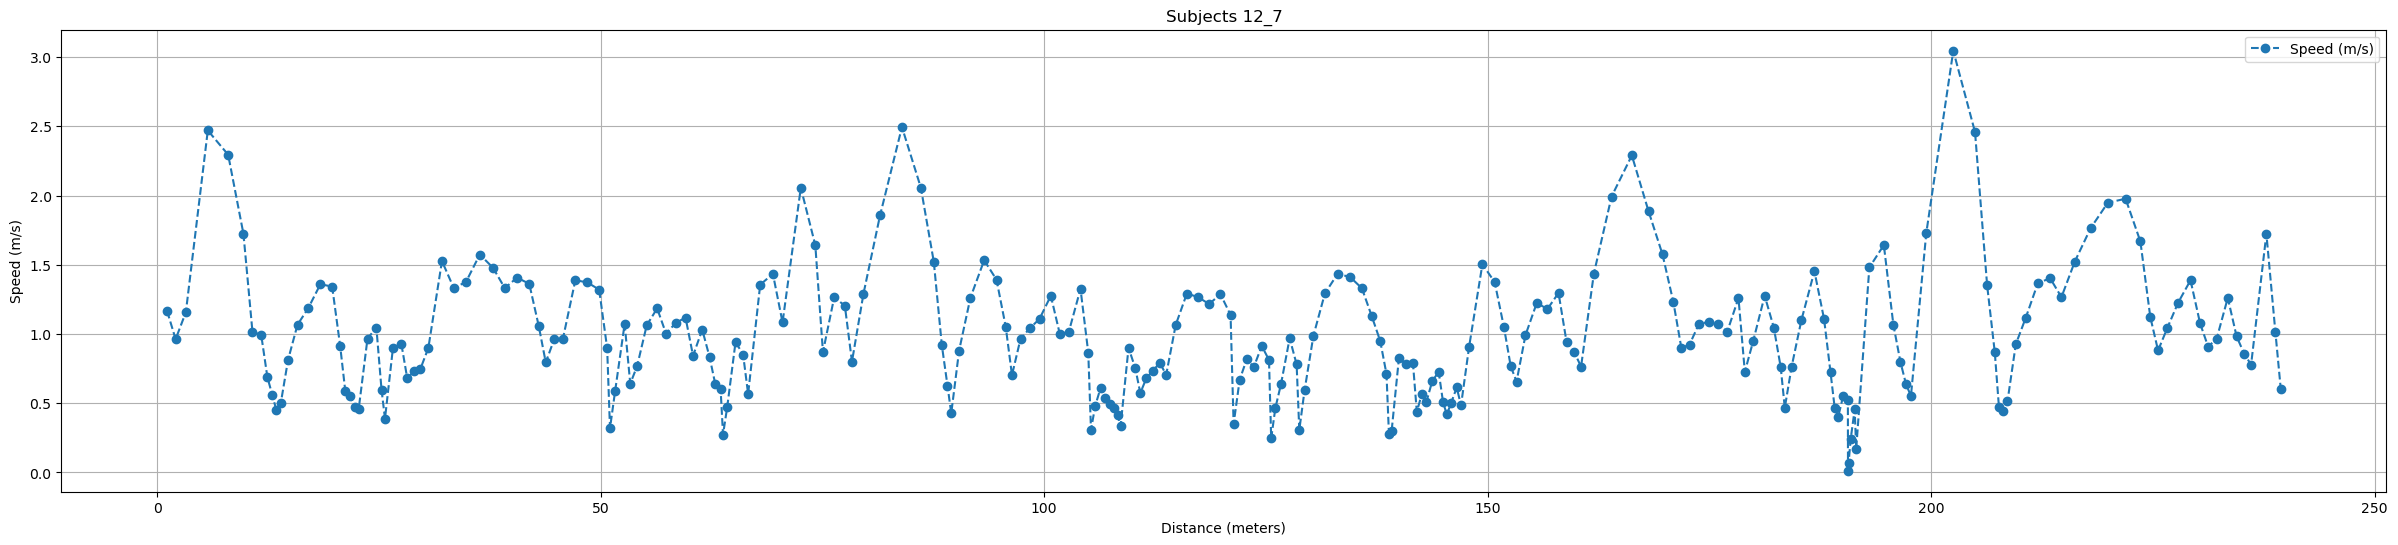

Total distance traveled for 12_0: 502.63 meters
   time_s  distance_m  delta_time_s   speed_mps
0   0.000    0.000000           NaN         NaN
1   0.021   41.925308         0.100  419.253081
2   1.042    1.767499         1.021    1.731145
3   2.049    1.869364         1.007    1.856369
4   3.036    0.619685         0.987    0.627847
5   4.017    1.837479         0.981    1.873068
6   5.017    0.612499         1.000    0.612499
7   6.028    0.286116         1.011    0.283003
8   7.025    0.239618         0.997    0.240339
9   8.047    1.820571         1.022    1.781380


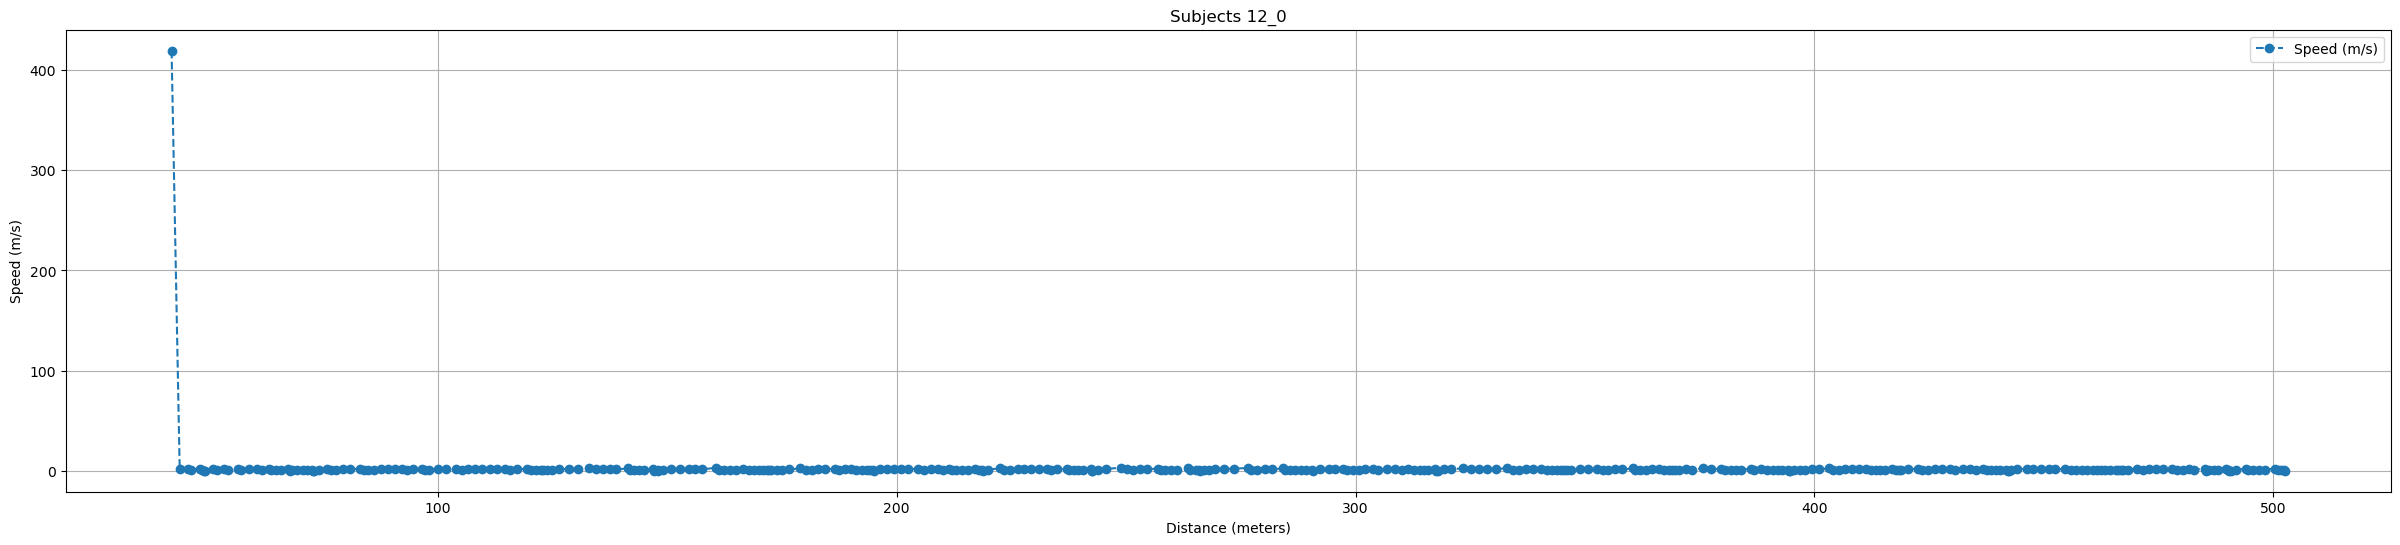

Total distance traveled for 12_13: 143.71 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   1.077    0.273154         1.077   0.253625
2   1.973    0.357924         0.896   0.399469
3   2.962    0.093658         0.989   0.094699
4   3.965    0.051463         1.003   0.051309
5   4.963    0.200249         0.998   0.200651
6   5.967    0.336470         1.004   0.335129
7   6.962    0.240254         0.995   0.241461
8   8.028    0.345918         1.066   0.324501
9   8.959    0.378783         0.931   0.406856


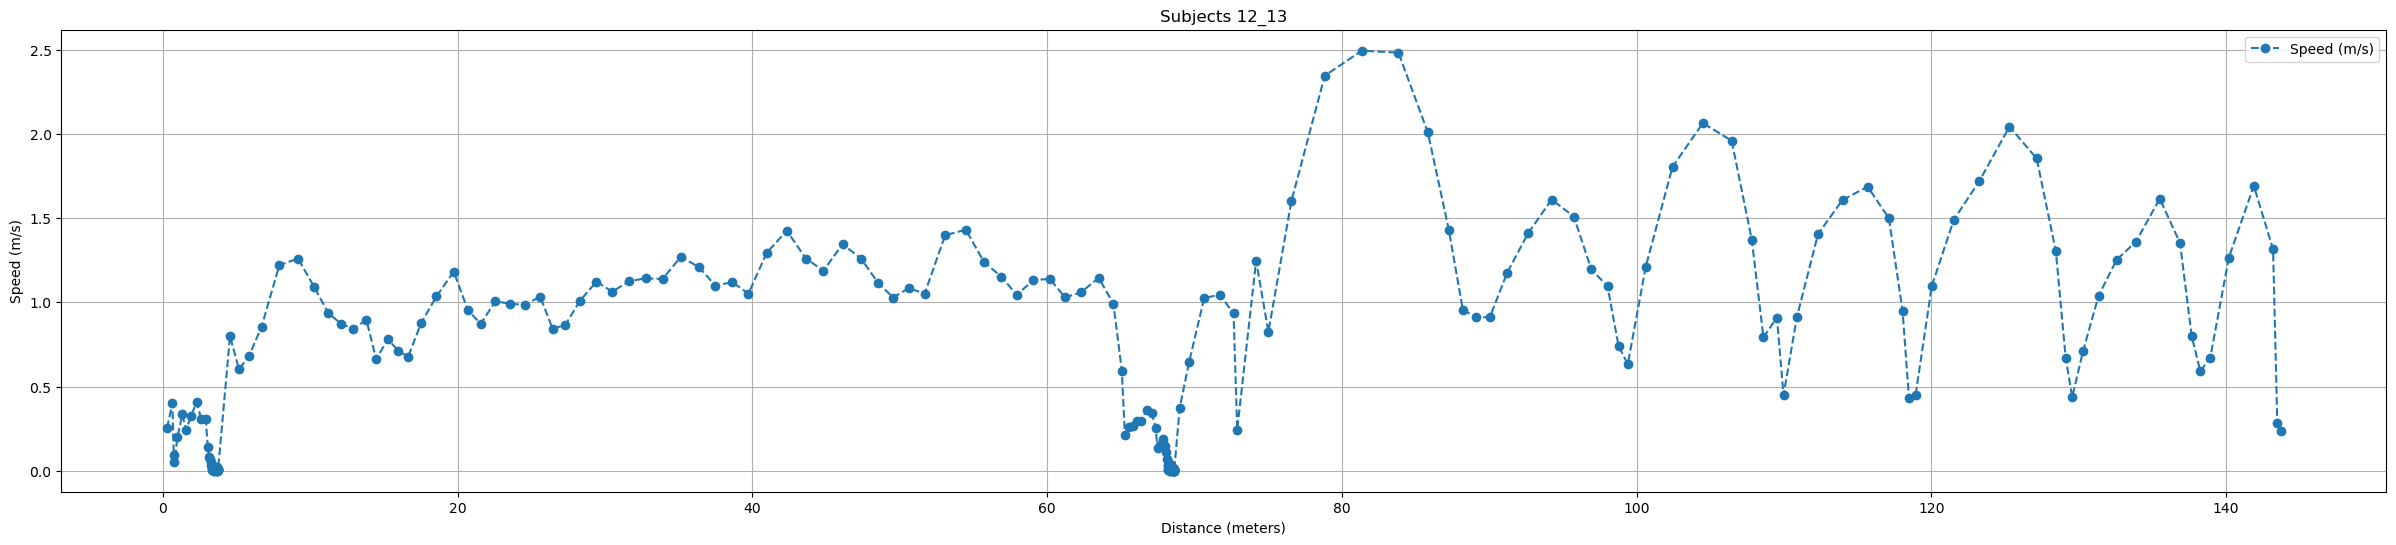

Total distance traveled for 12_12: 198.97 meters
   time_s  distance_m  delta_time_s  speed_mps
0   0.000    0.000000           NaN        NaN
1   0.274   11.806063         0.274  43.087822
2   1.217    2.191101         0.943   2.323543
3   2.241    1.891695         1.024   1.847359
4   3.219    1.621152         0.978   1.657620
5   4.239    0.824328         1.020   0.808165
6   5.222    0.768430         0.983   0.781719
7   6.233    0.299756         1.011   0.296494
8   7.231    0.239606         0.998   0.240086
9   8.223    0.117875         0.992   0.118825


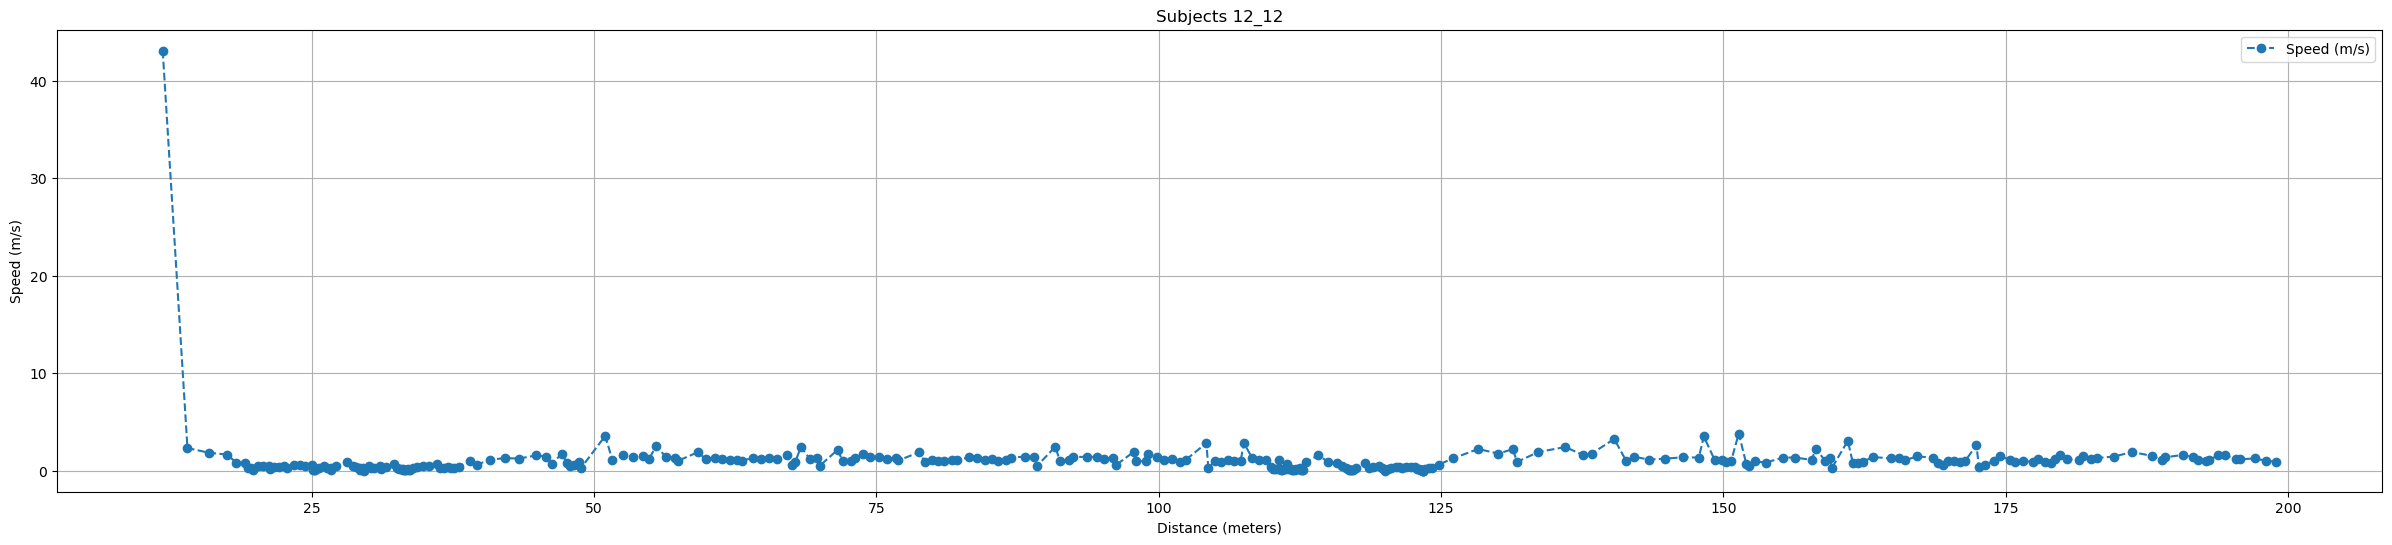

In [ ]:
import math

# Function to filter tests by subject name
def filter_tests_by_subject(selection, subject_name):
    return [test for test in selection if test.filename.startswith(subject_name)]

# Example usage of subject 12
subject_name = '12'  # Replace with the desired subject name
filtered_selection = filter_tests_by_subject(selection, subject_name)

# Proceed with the filtered selection
for test in filtered_selection:
    positions_data = test.positions.copy()  # Important to copy the data to avoid modifying the original

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points (protects against index errors)
    distances = [0] + [
        crowDist(positions_data.iloc[i-1], positions_data.iloc[i])
        for i in range(1, len(positions_data))
    ]
    positions_data['distance_m'] = distances

    # Total distance
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate time difference between measurement points
    positions_data['delta_time_s'] = positions_data['time_s'].diff()

    # Protect against division by small values or zero
    min_time_threshold = 0.1  # Minimum allowed time difference in seconds
    positions_data['delta_time_s'] = positions_data['delta_time_s'].clip(lower=min_time_threshold)

    # Calculate speed in m/s
    positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['delta_time_s']

    #Show the first 10 rows of data
    print(positions_data[['time_s', 'distance_m', 'delta_time_s', 'speed_mps']].head(10))

    # Plot for speed vs distance
    plt.figure(figsize=(30, 6))
    plt.plot(positions_data['distance_m'].cumsum(), positions_data['speed_mps'], marker='o', linestyle='--', label='Speed (m/s)')
    plt.xlabel('Distance (meters)')
    plt.ylabel('Speed (m/s)')
    plt.title(f"Subjects {test.filename}")
    plt.legend()
    plt.grid()
    plt.show()


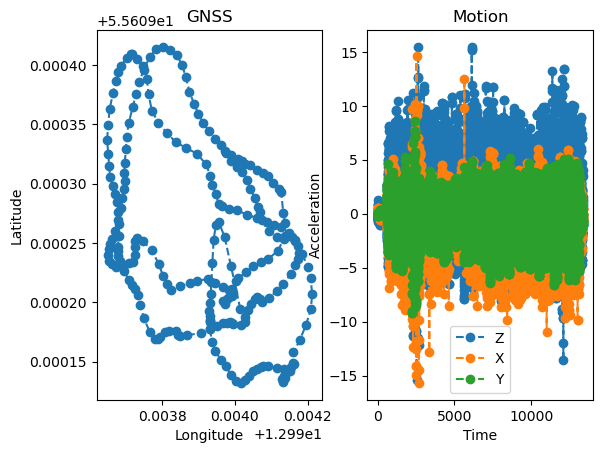

In [43]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()
